# End-to-End Sales Forecasting & Demand Intelligence System

### Final Internship Project

**Intern:** Naman Arora

---

## Project Overview

This project develops an end-to-end Sales Forecasting and Demand Intelligence System that analyzes historical retail sales data to forecast future demand, detect anomalous sales patterns, segment products based on demand behavior, and provide an interactive dashboard for business decision-making.

The project combines statistical forecasting, machine learning, clustering, and data visualization techniques to support data-driven inventory planning.

## Objectives

- Analyze historical sales trends and seasonality.
- Forecast future sales using multiple forecasting models.
- Detect unusual sales patterns.
- Segment products based on demand characteristics.
- Develop an interactive Streamlit dashboard.
- Generate actionable business insights.

# Task 1 — Data Loading, Merging & Deep Exploration

## 1. Load the Superstore Sales CSV using Pandas


In [74]:
import pandas as pd
df = pd.read_csv("data/train.csv")
print(df.head(5))


   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

## 2. Parse the Order Date and Ship Date columns as proper datetime objects

In [75]:
# Convert date columns into datetime format

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


## 3. Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season


In [76]:
# Extract Year
df["Year"] = df["Order Date"].dt.year

# Extract Month
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

# Extract Week Number
df["Week Number"] = df["Order Date"].dt.isocalendar().week.astype(int)

# Extract Day of Week
df["Day of Week"] = df["Order Date"].dt.day_name()

# Extract Quarter
df["Quarter"] = df["Order Date"].dt.quarter

# Function to assign seasons
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

# Season column
df["Season"] = df["Month"].apply(get_season)

df[[
    "Order Date",
    "Year",
    "Month",
    "Month Name",
    "Week Number",
    "Day of Week",
    "Quarter",
    "Season"
]].head()

,Order Date,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
1,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
2,2017-06-12,2017,6,June,24,Monday,2,Summer
3,2016-10-11,2016,10,October,41,Tuesday,4,Autumn
4,2016-10-11,2016,10,October,41,Tuesday,4,Autumn


## 4. Check for missing values, duplicates, and data type issues

In [77]:
# Missing Values
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

# Duplicate Records
print(f"Duplicate Records: {df.duplicated().sum()}")

# Data Types
df.dtypes

Duplicate Records: 0


Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Year                      int32
Month                     int32
Month Name                  str
Week Number               int64
Day of Week                 str
Quarter                   int32
Season                      str
dtype: object

## 5. Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)

In [78]:
# Sale by date
daily_sales = (
    df.groupby("Order Date", as_index=False)["Sales"]
      .sum()
)

# Sale by week
weekly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

# Sale by month
monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="ME"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

print("Daily Sales:")
print(daily_sales.head())

print("Weekly Sales:")
print(weekly_sales.head())

print("Monthly Sales:")
print(monthly_sales.head())

Daily Sales:
  Order Date     Sales
0 2015-01-03    16.448
1 2015-01-04   288.060
2 2015-01-05    19.536
3 2015-01-06  4407.100
4 2015-01-07    87.158
Weekly Sales:
  Order Date     Sales
0 2015-01-04   304.508
1 2015-01-11  4619.108
2 2015-01-18  4130.533
3 2015-01-25  3092.544
4 2015-02-01  2527.914
Monthly Sales:
  Order Date      Sales
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


#### Daily, weekly, and monthly sales aggregations are created because different forecasting models and business analyses require different levels of time granularity. Daily data captures fine-grained fluctuations, weekly data reduces short-term noise, and monthly data highlights long-term trends and seasonality.

## 6. Answer these questions in your notebook with data to back each one:
1. Which product category generates the highest total revenue?
2. Which region has the most consistent sales growth over 4 years?
3. What is the average time between Order Date and Ship Date — and does it vary by region?
4. Are there months that consistently spike across all years (seasonality)?

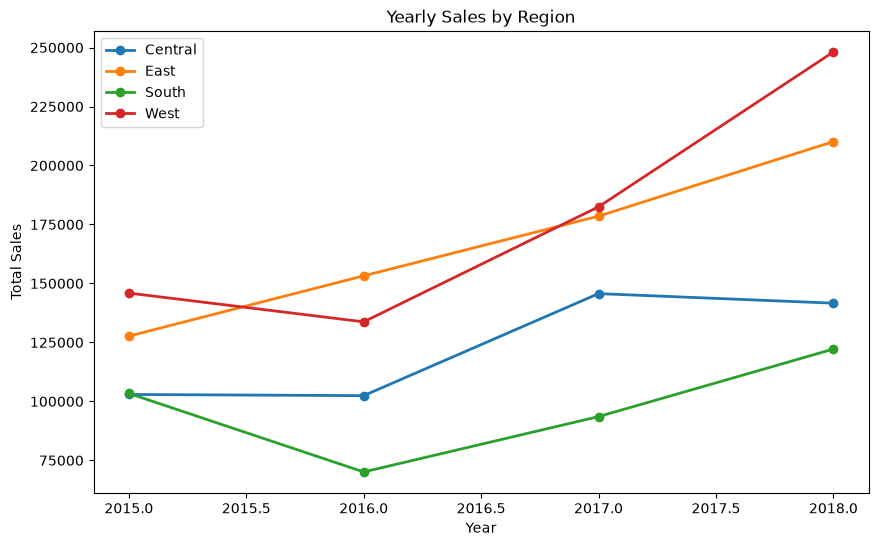

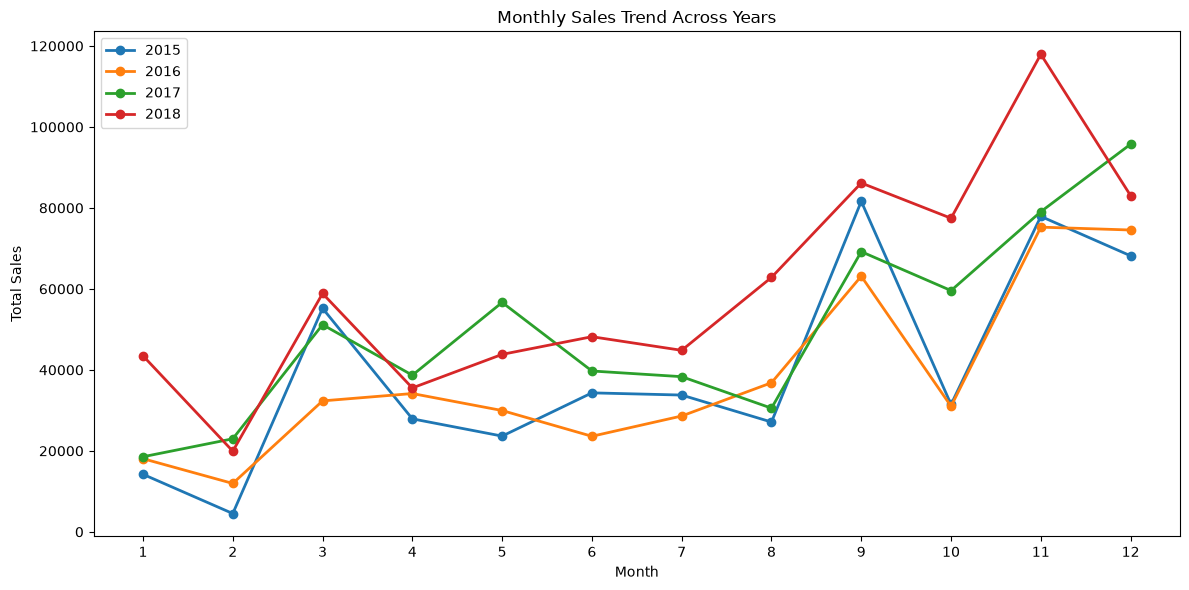

In [79]:
# 1. Product category generates the highest total revenue
highest_sales_category = (
    df.groupby("Category", as_index=False)["Sales"]
      .sum()
      .sort_values(by="Sales", ascending=False)
)

highest_sales_category.head(1)

# 2.Region with the most consistent sales growth over 4 years
import matplotlib.pyplot as plt

region_sales = (
    df.groupby(["Year", "Region"], as_index=False)["Sales"]
      .sum()
)

plt.figure(figsize=(10,6))

for region in region_sales["Region"].unique():

    temp = region_sales[region_sales["Region"] == region]

    plt.plot(
        temp["Year"],
        temp["Sales"],
        marker="o",
        linewidth=2,
        markersize=6,
        label=region
    )

plt.title("Yearly Sales by Region")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.legend()


plt.savefig("charts/yearly_sales_by_region.png")
plt.show()

# Therefore, the region with the most consistent sales growth 
# over 4 years can be determined by analyzing the plotted lines 
# for each region. The region with a steady upward trend 
# without significant fluctuations would be considered the 
# most consistent.

# 3.The average time between Order Date and Ship Date — 
# and does it vary by region

# Calculate Shipping Days
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

# Average Shipping Time by Region
shipping_time = (
    df.groupby("Region", as_index=False)["Shipping Days"]
      .mean()
      .sort_values(by="Shipping Days", ascending=False)
)

shipping_time

#4. Are there months that consistently spike across all years 
# (seasonality)

# Monthly Sales by Year
monthly_pattern = (
    df.groupby(["Year", "Month"], as_index=False)["Sales"]
      .sum()
)

monthly_pattern.head()

plt.figure(figsize=(12,6))

for year in sorted(monthly_pattern["Year"].unique()):

    temp = monthly_pattern[
        monthly_pattern["Year"] == year
    ]

    plt.plot(
        temp["Month"],
        temp["Sales"],
        marker="o",
        linewidth=2,
        label=year
    )

plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend Across Years")
plt.legend()
plt.tight_layout()
plt.savefig("charts/monthly_sales_trend_across_years.png")
plt.show()





#### Therefore, the region with the most consistent sales growth over 4 years can be determined by analyzing the plotted lines for each region. The region with a steady upward trend without significant fluctuations would be considered the most consistent.

#### The monthly sales trends indicate clear seasonality. March, September, and November consistently experience higher sales across the four-year period, suggesting recurring periods of increased customer demand. These seasonal peaks can help businesses optimize inventory planning, staffing, and promotional campaigns.


# Task 2 — Time Series Analysis & Decomposition


## 1. Plot the Overall Monthly Sales Trend Across All 4 Years

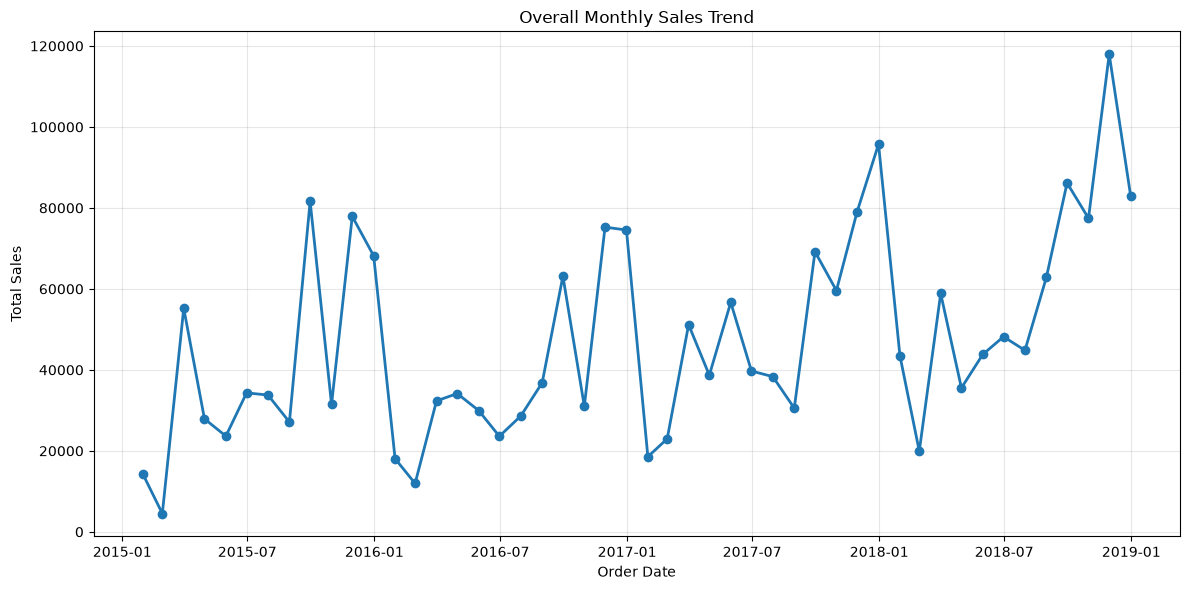

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Overall Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("charts/overall_monthly_sales_trend.png")
plt.show()

## 2. Apply Time Series Decomposition (using statsmodels) to break the sales signal into:
1. Trend component
2. Seasonal component
3. Residual/noise componen

## 3. Plot all 4 components clearly on one figure



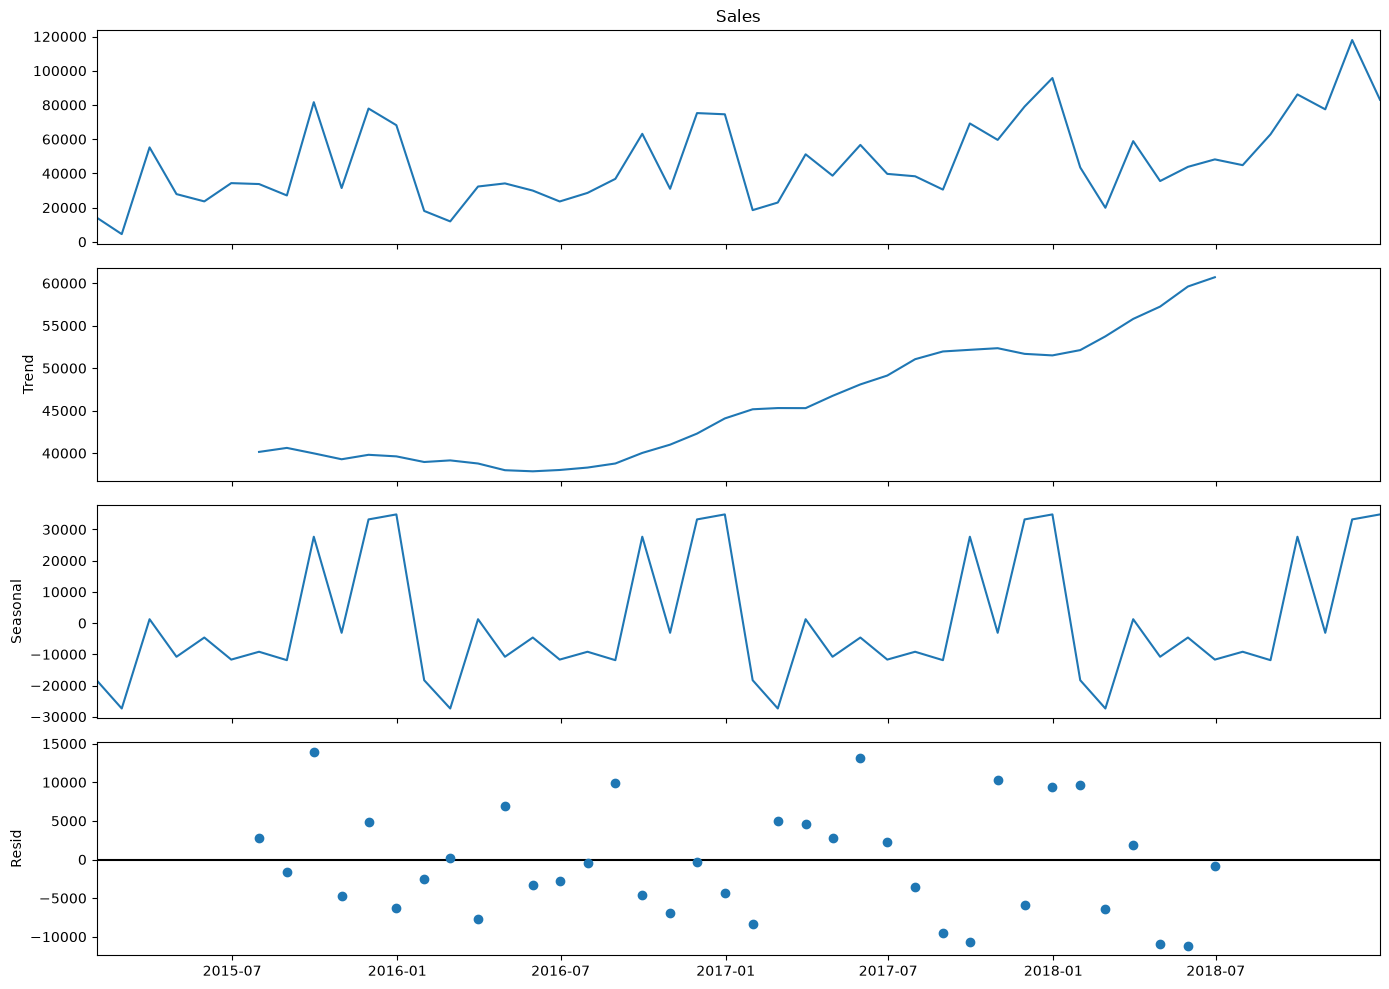

In [81]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Set Order Date as index
monthly_ts = monthly_sales.set_index("Order Date")

monthly_ts.head()
decomposition = seasonal_decompose(
    monthly_ts["Sales"],
    model="additive",
    period=12
)
fig = decomposition.plot()

fig.set_size_inches(14, 10)

plt.tight_layout()

plt.savefig("charts/time_series_decomposition.png")
plt.show()

## ## Observations

1. The trend component shows a gradual upward movement over the four-year period, indicating that overall sales have generally increased over time.

2. The seasonal component displays recurring patterns, suggesting that sales follow predictable seasonal behavior across different months.

3. The residual component captures random fluctuations that are not explained by the trend or seasonal effects, indicating occasional unexpected variations in sales.

4. Since both trend and seasonality are present, decomposition confirms that the data is suitable for time series forecasting models such as SARIMA and Prophet.

## 5. Checking for stationarity using the Augmented Dickey-Fuller (ADF) Test — explain in plain English what stationarity means and what your test result tells you

In [82]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_ts["Sales"])

print("ADF Statistic :", adf_result[0])
print("P-value :", adf_result[1])

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430768
P-value : 0.00027791039276670677

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


### Plain English Interpretation

A stationary time series is one whose overall behavior remains stable over time. This means that its average value and variation do not change significantly, making future patterns easier for forecasting models to learn.

The Augmented Dickey-Fuller (ADF) Test returned a **p-value of 0.000277**, which is less than **0.05**. This means the monthly sales series is **stationary**, so there is enough statistical evidence that the data is stable for time series forecasting. Therefore, **differencing is not required**, and the original monthly sales series can be used for building forecasting models.

## 6. Apply differencing if the series is non-stationary and re-test


### ADF Test Interpretation

The ADF test produced a p-value of **0.000277**, which is less than the significance level of **0.05**. Therefore, we reject the null hypothesis and conclude that the monthly sales series is stationary. Since the data is already stationary, differencing is not required before building forecasting models.

# Task 3 — Sales Forecasting using 3 Different Models

# Model 1 — SARIMA (Statistical Model)

SARIMA (Seasonal AutoRegressive Integrated Moving Average) is a statistical time series forecasting model that captures trend, seasonality, and autocorrelation in historical sales data.

For this project, SARIMA is used to forecast monthly sales for the next three months.

## 3. Choose appropriate (p, d, q) and seasonal (P, D, Q, m) parameters — document why you chose them
### Selected Parameters

### Parameter Selection and Justification

- **p = 1** → One previous month's sales are used to predict the next month's sales.
- **d = 0** → The ADF test confirmed that the monthly sales series is stationary, so differencing was not required.
- **q = 1** → One previous forecast error is used to improve future predictions.
- **P = 1** → One seasonal autoregressive term is used to capture yearly seasonal patterns.
- **D = 0** → Seasonal differencing was not required because the series was already stationary.
- **Q = 1** → One seasonal moving average term is used to account for seasonal forecast errors.
- **m = 12** → The dataset contains monthly sales data, so one seasonal cycle consists of 12 months.

## 1. Install statsmodels (pip install statsmodels)


In [83]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

## 2. Fit a SARIMA model on monthly sales


In [84]:
train = monthly_ts.iloc[:-3]
test = monthly_ts.iloc[-3:]

sarima_model = SARIMAX(
    train["Sales"],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False, # let model train if not stationary also
    enforce_invertibility=False # Do not restrict the model unnecessarily 
)

sarima_result = sarima_model.fit()

print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood               -4869.109
Date:                            Fri, 10 Jul 2026   AIC                           9748.218
Time:                                    02:13:49   BIC                           9755.388
Sample:                                01-31-2015   HQIC                          9750.555
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8473      0.000   3365.256      0.000       0.847       0.848
ma.L1         -4.1589      0.002  -

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 4. Generate a 3-month future forecast with confidence intervals


In [85]:
forecast = sarima_result.get_forecast(steps=3)

'''
Forecasted Sales Values

The predicted monthly sales values are extracted from the 
forecast object for further analysis and visualization.
'''
forecast_values = forecast.predicted_mean

print(forecast_values)

''' 
Confidence Intervals

Confidence intervals provide a range within which the actual 
sales values are expected to lie with a certain level of 
confidence. They indicate the uncertainty associated with 
each forecast.
'''
confidence_intervals = forecast.conf_int()
print(confidence_intervals)

2018-10-31    3.681736e+16
2018-11-30    3.119396e+16
2018-12-31    2.642947e+16
Freq: ME, Name: predicted_mean, dtype: float64
            lower Sales  upper Sales
2018-10-31          NaN          NaN
2018-11-30          NaN          NaN
2018-12-31          NaN          NaN


## 5. Plot Actual vs Forecasted Sales

The actual sales values from the test set are compared with the forecasted sales generated by the SARIMA model. The confidence interval is also displayed to visualize the uncertainty associated with the predictions.

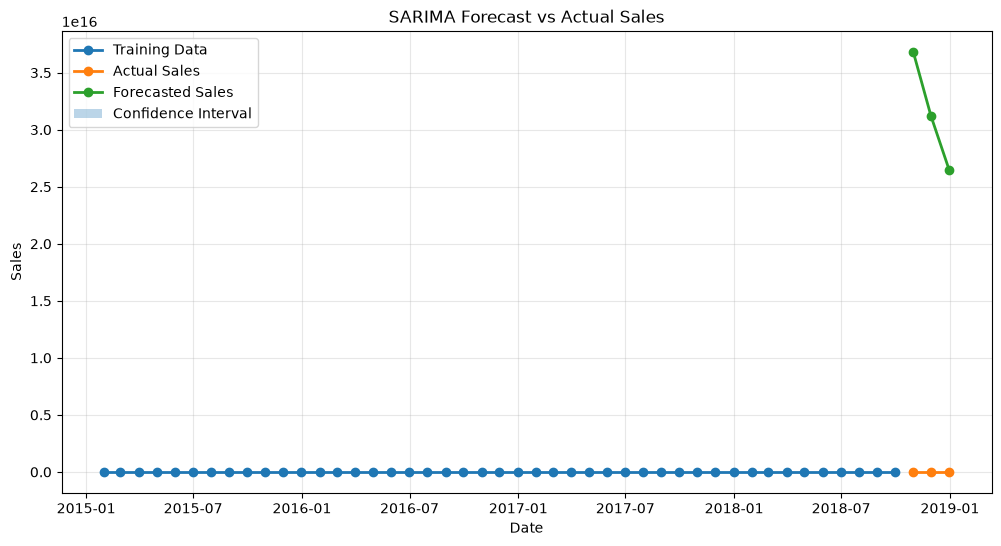

In [86]:
plt.figure(figsize=(12,6))

# Training Data
plt.plot(
    train.index,
    train["Sales"],
    marker="o",
    label="Training Data",
    linewidth=2
)

# Actual Sales
plt.plot(
    test.index,
    test["Sales"],
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

# Forecasted Sales
plt.plot(
    forecast_values.index,
    forecast_values,
    marker="o",
    linewidth=2,
    label="Forecasted Sales"
)

# Confidence Interval
plt.fill_between(
    confidence_intervals.index,
    confidence_intervals.iloc[:,0],
    confidence_intervals.iloc[:,1],
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("SARIMA Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(alpha=0.3)

plt.savefig("charts/sarima_forecast.png")

plt.show()

# Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)


## 1. Install Prophet (pip install prophet)


## 2. Prepare data in Prophet's required format (ds, y columns)


## Prepare Data for Prophet

Facebook Prophet requires the input data to contain two columns:

- **ds** → Date column
- **y** → Target variable (Sales)

The monthly sales dataset is converted into Prophet's required format before training the model.

In [87]:
# just to check if reset_index is required or not
# print(daily_sales.head())

prophet_df = daily_sales.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

prophet_df.head()

,ds,y
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


## 3. Fit the model and generate a 3-month forecast


In [88]:
from prophet import Prophet

prophet_model = Prophet()

prophet_model.fit(prophet_df)

''' 
Generate a 3-Month Forecast

After training, the Prophet model is used to forecast sales 
for the next three months based on the learned trend and 
seasonality.
'''
future = prophet_model.make_future_dataframe(
    periods=90,
    freq="D"
)

forecast = prophet_model.predict(future)

forecast.tail()

02:13:49 - cmdstanpy - INFO - Chain [1] start processing
02:13:49 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1315,2019-03-26,2360.856542,82.344797,5582.622459,2358.237075,2363.325260,548.803774,548.803774,548.803774,362.644823,362.644823,362.644823,186.158951,186.158951,186.158951,0.0,0.0,0.0,2909.660316
1316,2019-03-27,2361.800459,-270.802078,5155.306026,2359.133049,2364.339800,18.716646,18.716646,18.716646,-107.842722,-107.842722,-107.842722,126.559368,126.559368,126.559368,0.0,0.0,0.0,2380.517106
1317,2019-03-28,2362.744376,-931.159881,4542.241176,2360.029162,2365.356743,-621.181277,-621.181277,-621.181277,-688.035889,-688.035889,-688.035889,66.854612,66.854612,66.854612,0.0,0.0,0.0,1741.563099
1318,2019-03-29,2363.688293,-406.026490,5148.287377,2360.926708,2366.359904,-62.251320,-62.251320,-62.251320,-70.394747,-70.394747,-70.394747,8.143427,8.143427,8.143427,0.0,0.0,0.0,2301.436973
1319,2019-03-30,2364.632210,5.178108,5346.025397,2361.824255,2367.339871,315.626324,315.626324,315.626324,364.200481,364.200481,364.200481,-48.574157,-48.574157,-48.574157,0.0,0.0,0.0,2680.258534


## 5. Extract and interpret the weekly and yearly seasonality components

#### The forecast generated by Prophet is visualized to compare historical sales with the predicted sales for the next three months. The shaded region represents the confidence interval around the forecast.

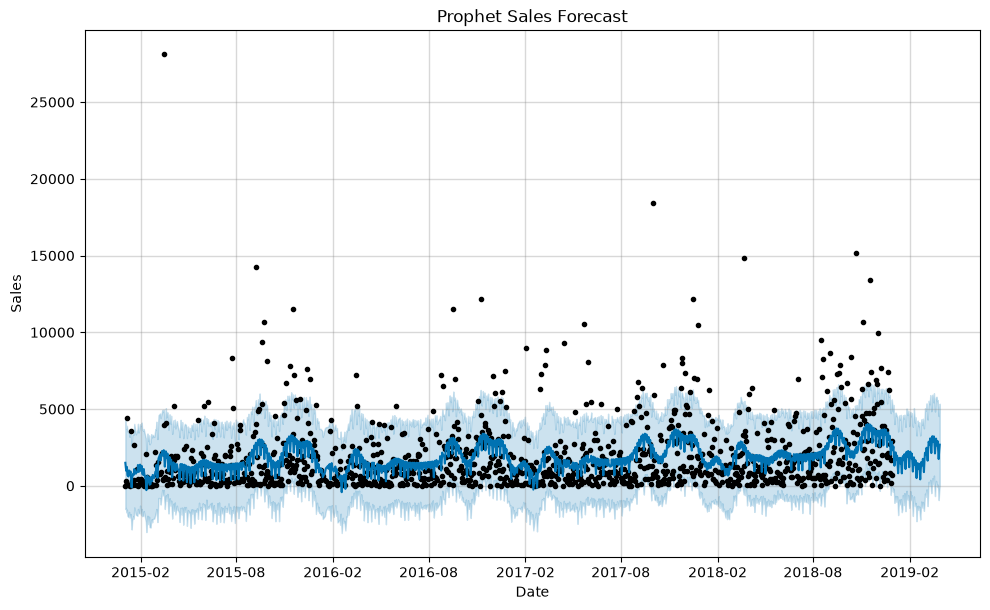

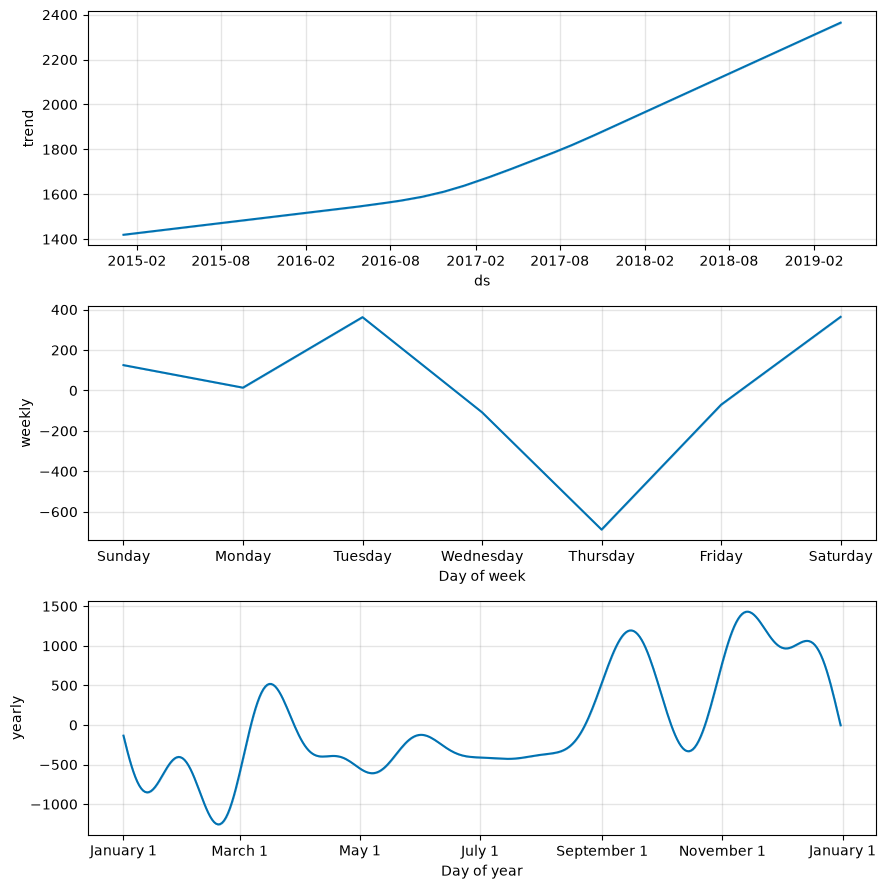

In [89]:
fig1 = prophet_model.plot(forecast)

plt.title("Prophet Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.savefig("charts/prophet_forecast.png")

plt.show()

# Trend and Seasonality Components
''' 
Prophet automatically decomposes the forecast into its 
underlying components, including the overall trend and seasonal 
effects. These components help explain how different time-based 
patterns contribute to the sales forecast.
'''

fig2 = prophet_model.plot_components(forecast)

plt.savefig("charts/prophet_components.png")

plt.show()

### Weekly Seasonality Observation

The weekly seasonality component indicates that sales tend to be higher on Tuesdays and Saturdays, while Thursdays consistently show the lowest sales activity. This suggests that customer purchasing behavior varies across the week.

### Trend Observation

The trend component shows a steady upward growth in sales over the observed period, indicating that the overall business performance has improved over time.

